In [1]:
import cv2
import numpy as np
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage
import matplotlib.pyplot as plt

# Cargar la imagen
image_path = r'Clenead_Images\XZ_Clean\xz00.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


In [3]:
# Definir umbrales
max_area_threshold = 10000 #10000
min_area_threshold = 0    # Umbral

# 1. Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(image, (3, 3), 0) #23,23,(<008) 5,5(blackers-009)

# 2. Binarizar usando umbral de Otsu
_, binary = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = cv2.bitwise_not(binary)

# 3. Operaciones morfológicas para limpiar pequeñas manchas y separar un poco las burbujas
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)) # 15 15, 3,3(blackers - 009)
binary_opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 4.Transformada de distanci
dist_transform = cv2.distanceTransform(binary_opened, cv2.DIST_L2, 3)

# 5. Encontrar los picos locales en la transformada de distancia
coordinates = peak_local_max(dist_transform, min_distance=5,threshold_abs=0.5) # 27 
local_max = np.zeros(dist_transform.shape, dtype=bool)
local_max[tuple(coordinates.T)] = True




# Etiquetar los picos para usarlos como marcadores en watershed
markers, _ = ndimage.label(local_max)

# 6.  la transformada de distancia negativa (para encontrar valles)
labels = watershed(-dist_transform, markers, mask=binary_opened)

# 7.Resultado
num_labels = labels.max()
areas = []
valid_count = 0


for lbl in range(1, num_labels+1):
    mask = (labels == lbl).astype(np.uint8)
    area = cv2.countNonZero(mask)
    bubble_coordinates = coordinates[np.where(mask[tuple(coordinates.T)] == 1)]
    x, y, w, h = cv2.boundingRect(mask)
    aspect_ratio = w / h if h > 0 else 0
    
    # Filtrar por área 
    if 0.7 <= aspect_ratio <= 2.5 and min_area_threshold <= area <= max_area_threshold:
        areas.append((lbl,area))
        valid_count += 1
areas = sorted(areas,key=lambda x: x[1])
gradient_colors = np.linspace(0,255,len(areas),dtype=np.uint8)
colored_result = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)

for i, (lbl, area) in enumerate(areas):
    # Asignar un color basado en el índice del gradiente
    color = (255 - gradient_colors[i], 0, gradient_colors[i])  # Azul -> Rojo
    colored_result[labels == lbl] = color

    



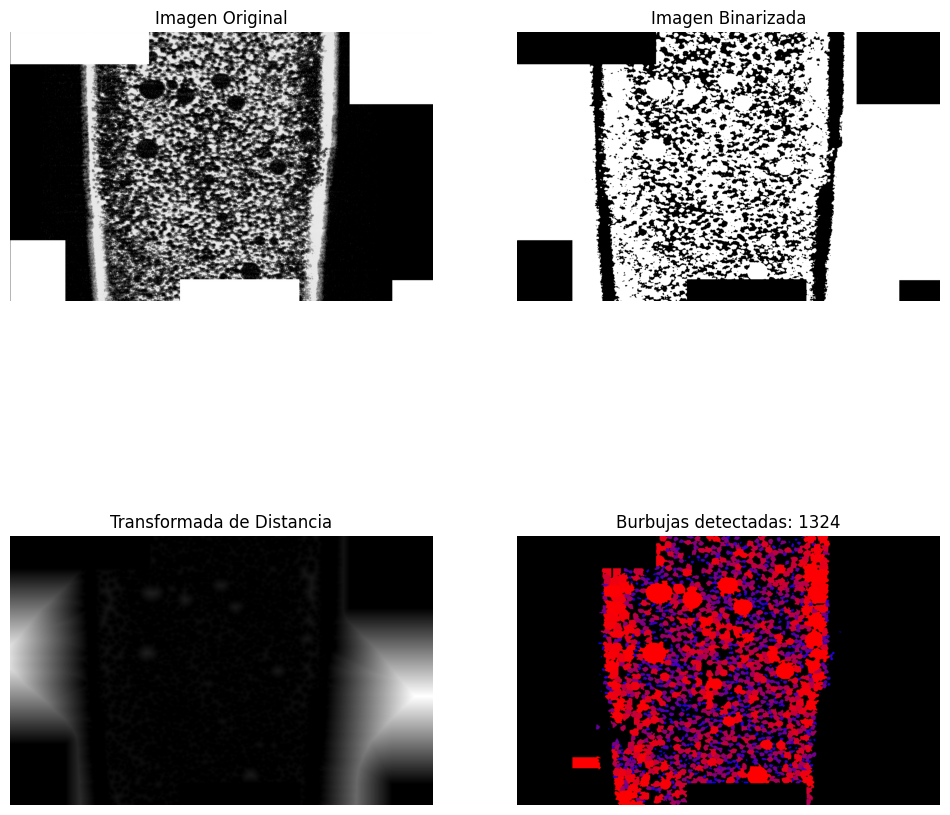

In [4]:
# 10. Visualizar los resultados
plt.figure(figsize=(12, 12))

# Subgráfico 1: Imagen original
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis('off')

# Subgráfico 2: Imagen binarizada
plt.subplot(2, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title("Imagen Binarizada")
plt.axis('off')

# Subgráfico 3: Transformada de distancia
plt.subplot(2, 2, 3)
plt.imshow(dist_transform, cmap='gray')
plt.title("Transformada de Distancia")
plt.axis('off')

# Subgráfico 4: Resultado final con burbujas detectadas
plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
plt.title(f"Burbujas detectadas: {len(areas)}")
plt.axis('off')

plt.show()
